# Ecuador_Earthquake_2016

[HumAID: Human-Annotated Disaster Incidents Data from Twitter](https://crisisnlp.qcri.org/humaid_dataset)

---

## A. Original

A annotated dataset about the Earth-quake occurred in Ecuador on April 16, 2016. The corpus contains 8360 tweets annotated for English and Spanish language but we only cover English in this work.

### Humanitarian categories
- Caution and advice
- Displaced people and evacuations
- Dont know cant judge
- Infrastructure and utility damage
- Injured or dead people
- Missing or found people
- Not humanitarian
- Other relevant information
- Requests or urgent needs
- Rescue volunteering or donation effort
- Sympathy and support


### Ref

Cinthia Sánchez, Andrés Abeliuk, and Barbara Poblete. 2025. Large Language Models in Crisis Informatics for Zero and Few-Shot Classification. ACM Trans. Web 19, 4, Article 45 (November 2025), 25 pages. https://doi.org/10.1145/3736160



## B. Data Processing

In [12]:
from pathlib import Path
import os
import pandas as pd

import configuration
from src import dataset_settings

from dotenv import load_dotenv
load_dotenv()

True

### B.1. Data Loading and Structural handling

In [14]:
dataset_path = Path(os.getenv("DATASETS_PATH")) / 'Ecuador_Earthquake_2016' / '2016_ecuador_eq_en.csv'

df = pd.read_csv(dataset_path, sep=',', encoding='utf_8')
df['id'] = df['id'].astype('int64')
df['event_type'] = 'earthquake'
df['event_name'] = 'Ecuador Earthquake 2016'
df['year'] = 2016
df['dataset'] = 'Ecuador_Earthquake_2016'
df['meta'] = df.apply(
    lambda x: {
        'file_name': '2016_ecuador_eq_en.csv',
        'url': x['url'],
        },
    axis=1)
df.rename(columns={'id': 'tweet_id', 'text': 'tweet_text', 'choose_one_category': 'humanitarian_label'}, inplace=True)
df['relevant']= df['crisis_related'].apply(lambda x: True if x == 'yes' else False)
df.drop(columns=[
    'crisis_related', 'screen_name', 'timestamp', 
    'choose_one_category_a1', 'choose_one_category_a2', 'choose_one_category_a3']
        , inplace=True)

In [ ]:
print(f'Total rows: {len(df)}')
df.head(10)

Total rows: 4192


,id,screen_name,text,url,timestamp,choose_one_category,crisis_related,choose_one_category_a1,choose_one_category_a2,choose_one_category_a3,event_type,event_name,year,dataset,meta
0,721627947832979456,ErikaGarza_Tv,The death toll is 77 in Ecuador after a 7.8 ea...,https://www.twitter.com/ErikaGarza_Tv/status/7...,2016-04-17 09:14:44,injured_or_dead_people,yes,injured_or_dead_people,injured_or_dead_people,injured_or_dead_people,earthquake,Ecuador Earthquake 2016,2016,Ecuador_Earthquake_2016,{'file_name': '2016_ecuador_eq_en.csv'}
1,721719744869478400,rr_rr_rr_11,Magnitude-7.8 earthquake hits Ecuador https://...,https://www.twitter.com/rr_rr_rr_11/status/721...,2016-04-17 15:19:30,other_useful_information,yes,other_useful_information,other_useful_information,other_useful_information,earthquake,Ecuador Earthquake 2016,2016,Ecuador_Earthquake_2016,{'file_name': '2016_ecuador_eq_en.csv'}
2,721706927881723904,LimAiYim,Retweeted EarthSky (@earthskyscience): Ecuado...,https://www.twitter.com/LimAiYim/status/721706...,2016-04-17 14:28:34,other_useful_information,yes,other_useful_information,other_useful_information,other_useful_information,earthquake,Ecuador Earthquake 2016,2016,Ecuador_Earthquake_2016,{'file_name': '2016_ecuador_eq_en.csv'}
3,721605773445324800,cachejobscom,"#jobs # #Major earthquake rocks Ecuador, killi...",https://www.twitter.com/cachejobscom/status/72...,2016-04-17 07:46:37,injured_or_dead_people,yes,injured_or_dead_people,injured_or_dead_people,injured_or_dead_people,earthquake,Ecuador Earthquake 2016,2016,Ecuador_Earthquake_2016,{'file_name': '2016_ecuador_eq_en.csv'}
4,721621866394177536,follownewsnow,#wikileaks Assange: 7.8 earthquake in #Ecuador...,https://www.twitter.com/follownewsnow/status/7...,2016-04-17 08:50:34,injured_or_dead_people,yes,injured_or_dead_people,injured_or_dead_people,injured_or_dead_people,earthquake,Ecuador Earthquake 2016,2016,Ecuador_Earthquake_2016,{'file_name': '2016_ecuador_eq_en.csv'}
5,721566686843940864,ITSBLAZE,first Japan gets rocked by a 7.4 earthquake no...,https://www.twitter.com/ITSBLAZE/status/721566...,2016-04-17 05:11:18,sympathy_and_emotional_support,yes,sympathy_and_emotional_support,sympathy_and_emotional_support,sympathy_and_emotional_support,earthquake,Ecuador Earthquake 2016,2016,Ecuador_Earthquake_2016,{'file_name': '2016_ecuador_eq_en.csv'}
6,721564624840040448,Youtube00000011,VIDEO: The moment Ecuador earthquake struck: A...,https://www.twitter.com/Youtube00000011/status...,2016-04-17 05:03:07,injured_or_dead_people,yes,injured_or_dead_people,injured_or_dead_people,injured_or_dead_people,earthquake,Ecuador Earthquake 2016,2016,Ecuador_Earthquake_2016,{'file_name': '2016_ecuador_eq_en.csv'}
7,721600981763559424,UnknownComment,Powerful earthquake kills at least 77 in Ecuad...,https://www.twitter.com/UnknownComment/status/...,2016-04-17 07:27:35,injured_or_dead_people,yes,injured_or_dead_people,injured_or_dead_people,injured_or_dead_people,earthquake,Ecuador Earthquake 2016,2016,Ecuador_Earthquake_2016,{'file_name': '2016_ecuador_eq_en.csv'}
8,721586376911806464,Reinilla,@BBCNews Nervous about the earthquake here in ...,https://www.twitter.com/Reinilla/status/721586...,2016-04-17 06:29:33,sympathy_and_emotional_support,yes,sympathy_and_emotional_support,sympathy_and_emotional_support,sympathy_and_emotional_support,earthquake,Ecuador Earthquake 2016,2016,Ecuador_Earthquake_2016,{'file_name': '2016_ecuador_eq_en.csv'}
9,721714594490626048,empireonenews,Powerful Ecuador Earthquake Leaves 41 People D...,https://www.twitter.com/empireonenews/status/7...,2016-04-17 14:59:02,injured_or_dead_people,yes,injured_or_dead_people,injured_or_dead_people,injured_or_dead_people,earthquake,Ecuador Earthquake 2016,2016,Ecuador_Earthquake_2016,{'file_name': '2016_ecuador_eq_en.csv'}


### B.2. Cleaning and Mapping
#### B.2.1. Remove duplicated

In [ ]:
# No duplicate tweet_id found
print(f"Number of duplicate tweets id: {df['id'].duplicated().sum()}")

Number of duplicate tweets id: 0


#### B.2.2. Map label

All lable is `Humanitarian aid` in crisis, so, all is `Positive` lable in **Binary Classification** Task

In [ ]:
print(df['humanitarian_label'].value_counts())

humanitarian_label
not_related_or_irrelevant                            1946
injured_or_dead_people                               1165
other_useful_information                              426
sympathy_and_emotional_support                        325
donation_needs_or_offers_or_volunteering_services     207
infrastructure_and_utilities_damage                    73
caution_and_advice                                     39
displaced_people_and_evacuations                        7
missing_trapped_or_found_people                         4
Name: count, dtype: int64


In [15]:
print(df['relevant'].value_counts())

relevant
True     2246
False    1946
Name: count, dtype: int64


In [17]:
import csv
df.to_csv( 'datasets/Ecuador_Earthquake_2016.csv', index=False, quoting=csv.QUOTE_ALL)

### B.3. Verifying

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4192 entries, 0 to 4191
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_id            4192 non-null   int64 
 1   tweet_text          4191 non-null   object
 2   url                 4192 non-null   object
 3   humanitarian_label  4192 non-null   object
 4   event_type          4192 non-null   object
 5   event_name          4192 non-null   object
 6   year                4192 non-null   int64 
 7   dataset             4192 non-null   object
 8   meta                4192 non-null   object
 9   relevant            4192 non-null   bool  
dtypes: bool(1), int64(2), object(7)
memory usage: 299.0+ KB


In [19]:
df.describe(include='all')

,tweet_id,tweet_text,url,humanitarian_label,event_type,event_name,year,dataset,meta,relevant
count,4.192000e+03,4191,4192,4192,4192,4192,4192.0,4192,4192,4192
unique,NaN,4173,4192,9,1,1,NaN,1,4192,2
top,NaN,Earthquake kills dozens in Ecuador: A huge ear...,https://www.twitter.com/ErikaGarza_Tv/status/7...,not_related_or_irrelevant,earthquake,Ecuador Earthquake 2016,NaN,Ecuador_Earthquake_2016,"{'file_name': '2016_ecuador_eq_en.csv', 'url':...",True
freq,NaN,4,1,1946,4192,4192,NaN,4192,1,2246
mean,7.784077e+17,NaN,NaN,NaN,NaN,NaN,2016.0,NaN,NaN,NaN
std,1.215622e+17,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
min,3.687977e+17,NaN,NaN,NaN,NaN,NaN,2016.0,NaN,NaN,NaN
25%,7.215928e+17,NaN,NaN,NaN,NaN,NaN,2016.0,NaN,NaN,NaN
50%,7.216521e+17,NaN,NaN,NaN,NaN,NaN,2016.0,NaN,NaN,NaN
75%,7.217282e+17,NaN,NaN,NaN,NaN,NaN,2016.0,NaN,NaN,NaN


<Axes: xlabel='relevant'>

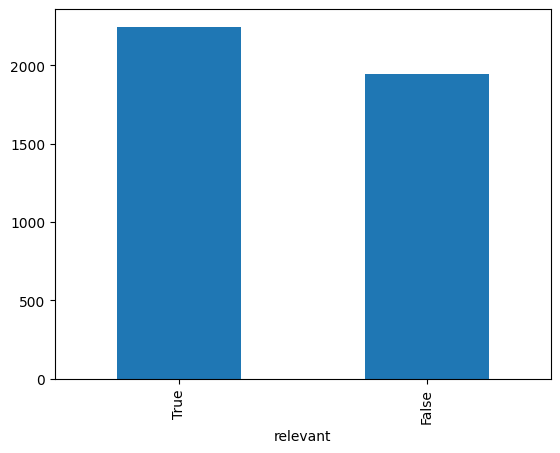

In [20]:
df['relevant'].value_counts().plot(kind='bar')

<Axes: xlabel='humanitarian_label'>

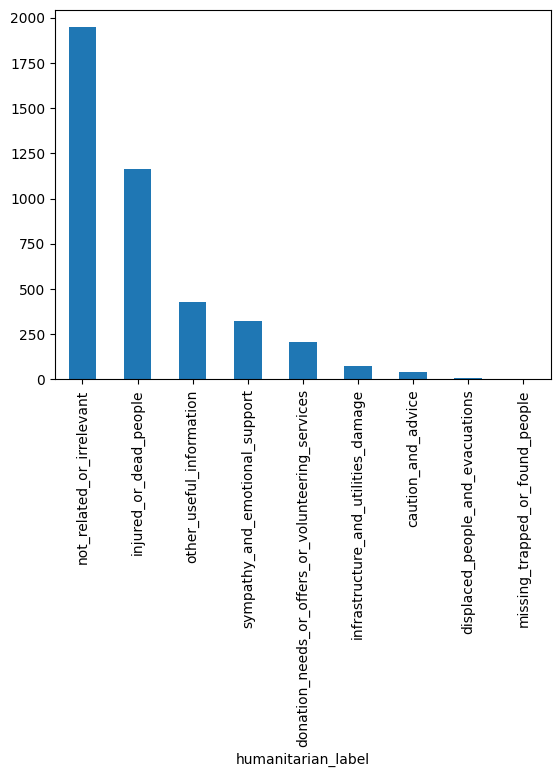

In [21]:
df['humanitarian_label'].value_counts().plot(kind='bar')

<Axes: xlabel='event_type'>

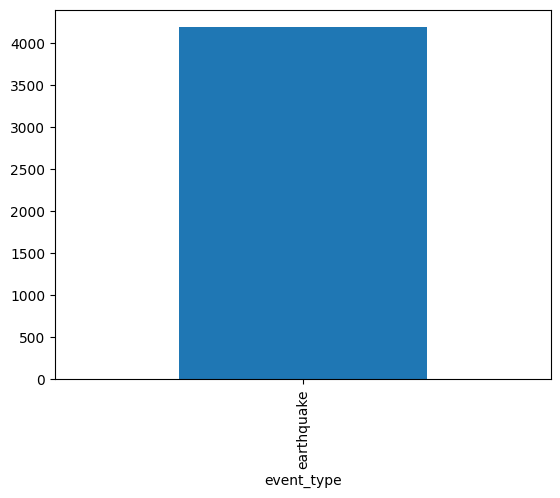

In [22]:
df['event_type'].value_counts().plot(kind='bar')